Fine-tune a pretrained transformer model such as BERT or DistilBERT to perform sentiment analysis on text data.<br>
The model should classify text into:<br>
1. Positive
2. Negative
3. Neutral (optional: multi-class support)


In [74]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================================

#core libraries
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

#data processing and evaluation libraries
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import classification_report, confusion_matrix

#transformers libraries
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

#ignore warnings
import warnings
warnings.filterwarnings("ignore")

c:\MiniForge\envs\intern_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [75]:
# ============================================================
# CELL 2: CHECK GPU / CUDA AVAILABILITY
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device being used:", device)

if device == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Training will run on CPU.")

Device being used: cuda
GPU Name: NVIDIA GeForce GTX 1050 Ti with Max-Q Design


First 5 rows of dataset:
                                                text sentiment
0                   need to leave now.. tweet laters   neutral
1   I don`t get as much time here either. It`s go...  negative
2  Jeff can`t get his visa in time to come visit ...  negative
3  Great for organization. I love the color schem...  positive
4                            First time to Twitter..   neutral

Label Distribution:
sentiment
neutral     14425
positive    12649
negative    11074
Name: count, dtype: int64


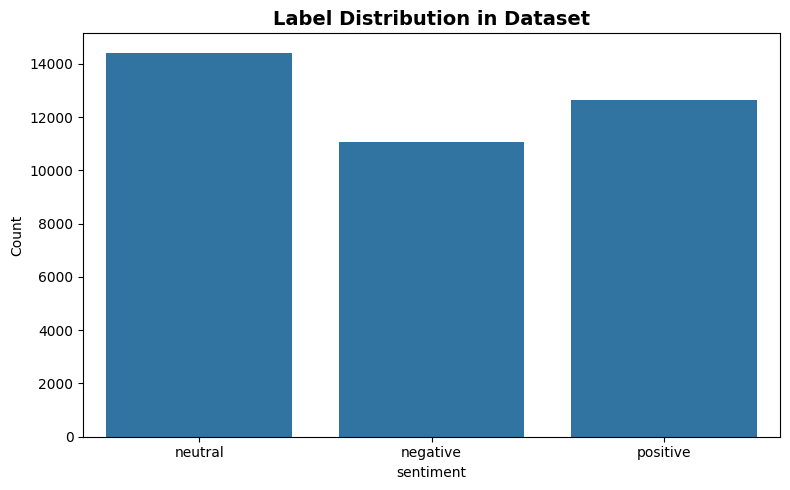

In [81]:
# ============================================================
# CELL 3: LOAD AND EXPLORE THE DATASET
# ============================================================

# Function to load and explore the dataset
def load_dataset(file_path):
    """
    Load and perform initial exploration of the dataset
    """
    # upload the dataset
    df = pd.read_csv(file_path)
    
    #check the first few rows of the dataset
    print("First 5 rows of dataset:")
    print(df.head())
    
    # check the label distribution
    print("\nLabel Distribution:")
    print(df['sentiment'].value_counts())
    
    # plot the label distribution with default colors
    plt.figure(figsize=(8, 5))
    sns.countplot(x='sentiment', data=df)
    plt.title('Label Distribution in Dataset', fontsize=14, fontweight='bold')
    plt.xlabel('sentiment')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('figures/label_distribution.png')
    plt.show()
    
    return df

# Load dataset
df = load_dataset('dataset/sentiment_dataset.csv')

Missing Values:
text         0
sentiment    0
dtype: int64

Missing Values After Cleaning:
text         0
sentiment    0
dtype: int64

Duplicate rows found: 0
Duplicates after removal: 0

First 5 rows after cleaning:
                                                text sentiment
0                   need to leave now.. tweet laters   neutral
1   I don`t get as much time here either. It`s go...  negative
2  Jeff can`t get his visa in time to come visit ...  negative
3  Great for organization. I love the color schem...  positive
4                            First time to Twitter..   neutral


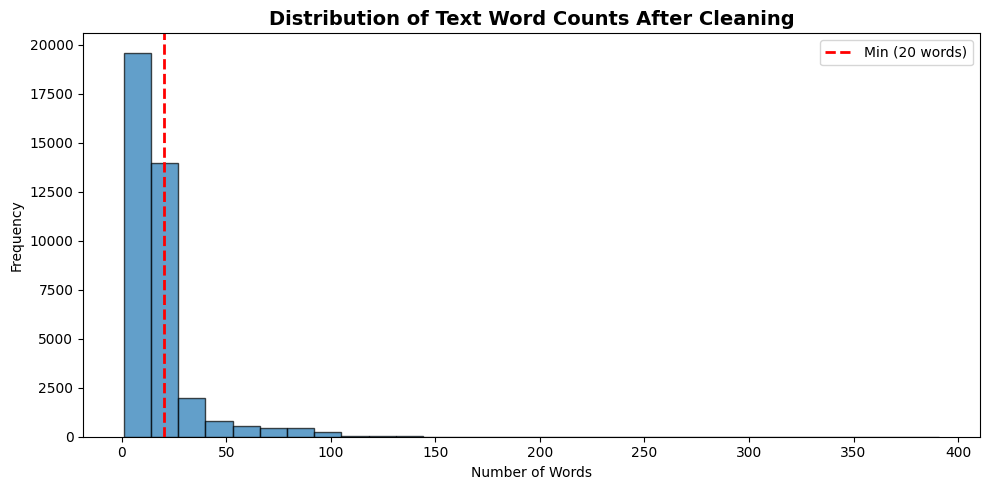

In [83]:
# ============================================================
# CELL 4: DATA CLEANING
# ============================================================

# perform data cleaning before preprocessing and training the models
def clean_dataset(df):
    """
    Clean the dataset by handling missing values, duplicates, and filtering reviews
    """
    # checking for missing values
    print("Missing Values:")
    print(df.isnull().sum())
    
    # since we got some missing values in the Text column, we will drop those rows
    df.dropna(subset=['text'], inplace=True)
    
    #again check for missing values
    print("\nMissing Values After Cleaning:")
    print(df.isnull().sum())
    
    #checking for duplicates
    print(f"\nDuplicate rows found: {df.duplicated().sum()}")
    
    #we also got some duplicate rows, we will drop those as well
    df.drop_duplicates(inplace=True)
    
    #again check for duplicates
    print(f"Duplicates after removal: {df.duplicated().sum()}")
    
    #checking the head of the dataset after preprocessing
    print("\nFirst 5 rows after cleaning:")
    print(df.head())
    
    # Visualize Text length distribution after cleaning
    plt.figure(figsize=(10, 5))
    plt.hist(df['text'].apply(lambda x: len(str(x).split())), bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Min (20 words)')
    plt.title('Distribution of Text Word Counts After Cleaning', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.savefig('figures/Text_length_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return df

# Clean dataset (before preprocessing)
df = clean_dataset(df)